# Quick check for the AWS trained autoencoder models


In [17]:
import json
import torch
import matplotlib.pyplot as plt
import numpy as np
import os
import glob
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import h5py
import pandas as pd
from scipy.spatial import procrustes

import sys
sys.path.append('/home/kurgyis/Research/VideoAnalysisTools/src/')
from behavioral_autoencoder.models import AutoEncoder


In [2]:
runs = ['20260827-165614', #fast cycle on largest session
        '20260827-165607',] # original parameters on largest session

runs_folder = '/mnt/m/Data/VideoAnalysisTools/runs/'

single_sess_folder = '/kd104_twNew_20221124_104921/checkpoints/kd104/'

checkpoint_nums = ['599','1499','3499','7499']

In [3]:
_session_training_dir = os.listdir(runs_folder + runs[0] + single_sess_folder)

checkpoints_dir = runs_folder + runs[1] + single_sess_folder + _session_training_dir[0] + '/'
os.listdir(checkpoints_dir)

['best_model.pt',
 'checkpoint_epoch_1099.pt',
 'checkpoint_epoch_1199.pt',
 'checkpoint_epoch_1299.pt',
 'checkpoint_epoch_1399.pt',
 'checkpoint_epoch_1499.pt',
 'checkpoint_epoch_1599.pt',
 'checkpoint_epoch_1699.pt',
 'checkpoint_epoch_1799.pt',
 'checkpoint_epoch_1899.pt',
 'checkpoint_epoch_199.pt',
 'checkpoint_epoch_1999.pt',
 'checkpoint_epoch_2099.pt',
 'checkpoint_epoch_2199.pt',
 'checkpoint_epoch_2299.pt',
 'checkpoint_epoch_2399.pt',
 'checkpoint_epoch_2499.pt',
 'checkpoint_epoch_2599.pt',
 'checkpoint_epoch_2699.pt',
 'checkpoint_epoch_2799.pt',
 'checkpoint_epoch_2899.pt',
 'checkpoint_epoch_299.pt',
 'checkpoint_epoch_2999.pt',
 'checkpoint_epoch_3099.pt',
 'checkpoint_epoch_3199.pt',
 'checkpoint_epoch_3299.pt',
 'checkpoint_epoch_3399.pt',
 'checkpoint_epoch_3499.pt',
 'checkpoint_epoch_3599.pt',
 'checkpoint_epoch_3699.pt',
 'checkpoint_epoch_3799.pt',
 'checkpoint_epoch_3899.pt',
 'checkpoint_epoch_399.pt',
 'checkpoint_epoch_3999.pt',
 'checkpoint_epoch_4099.pt',

In [4]:
config_file = checkpoints_dir + 'config.json'
with open(config_file, 'r') as f:
    config = json.load(f)

ae = AutoEncoder(config['model'])

checkpoint_data = torch.load(checkpoints_dir + 'checkpoint_epoch_' + 
                             checkpoint_nums[2] + '.pt', 
                             map_location='cpu', weights_only=False)

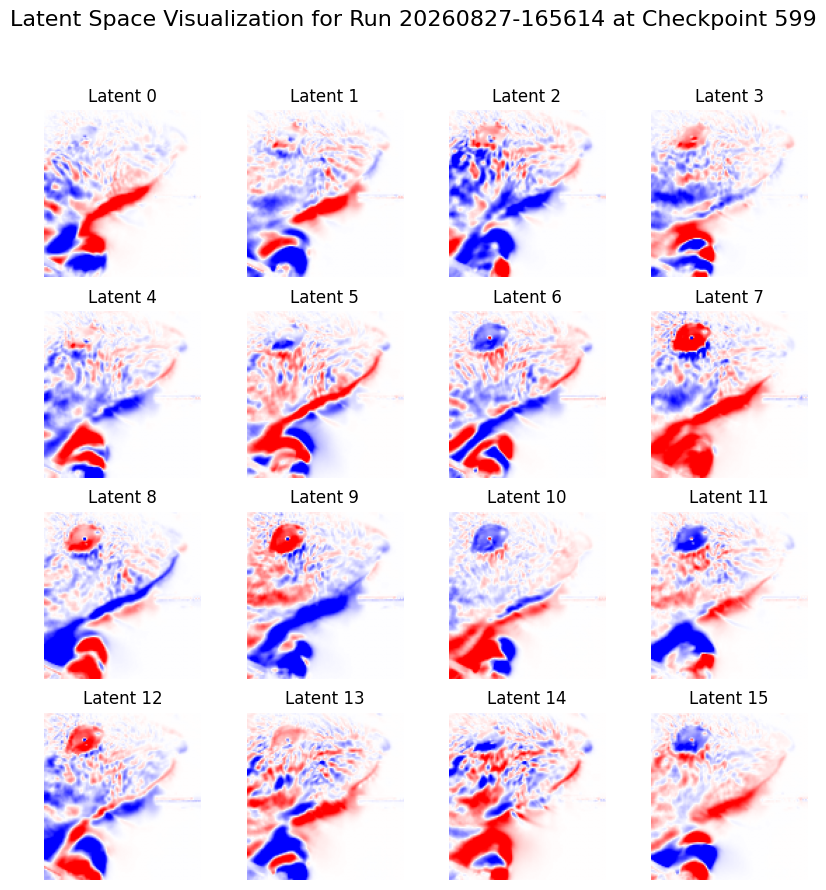

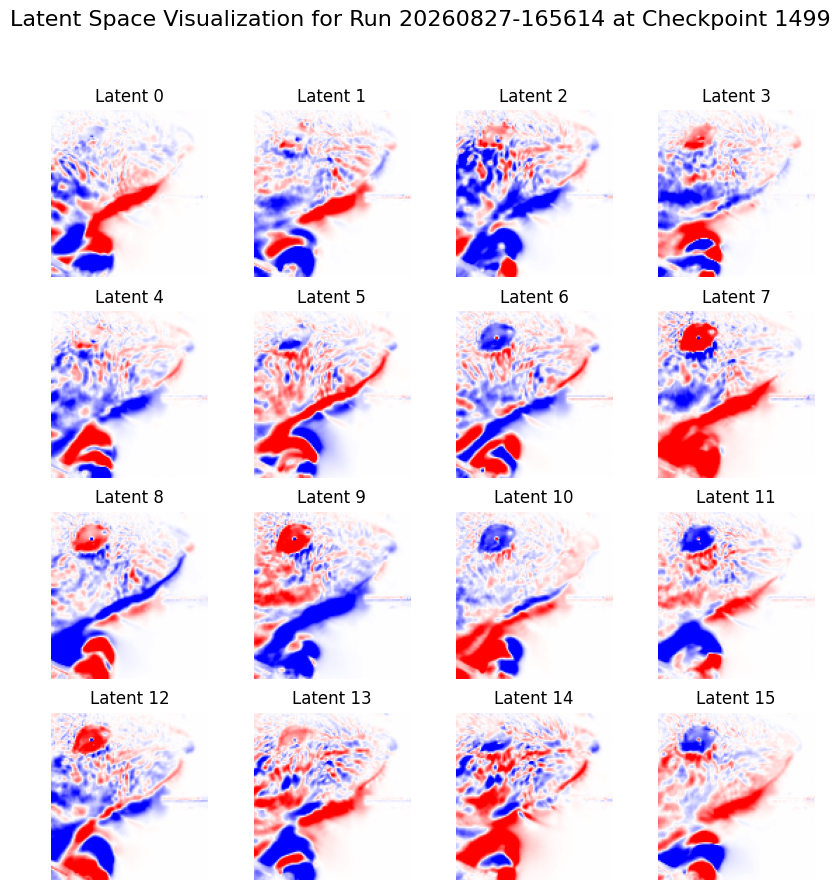

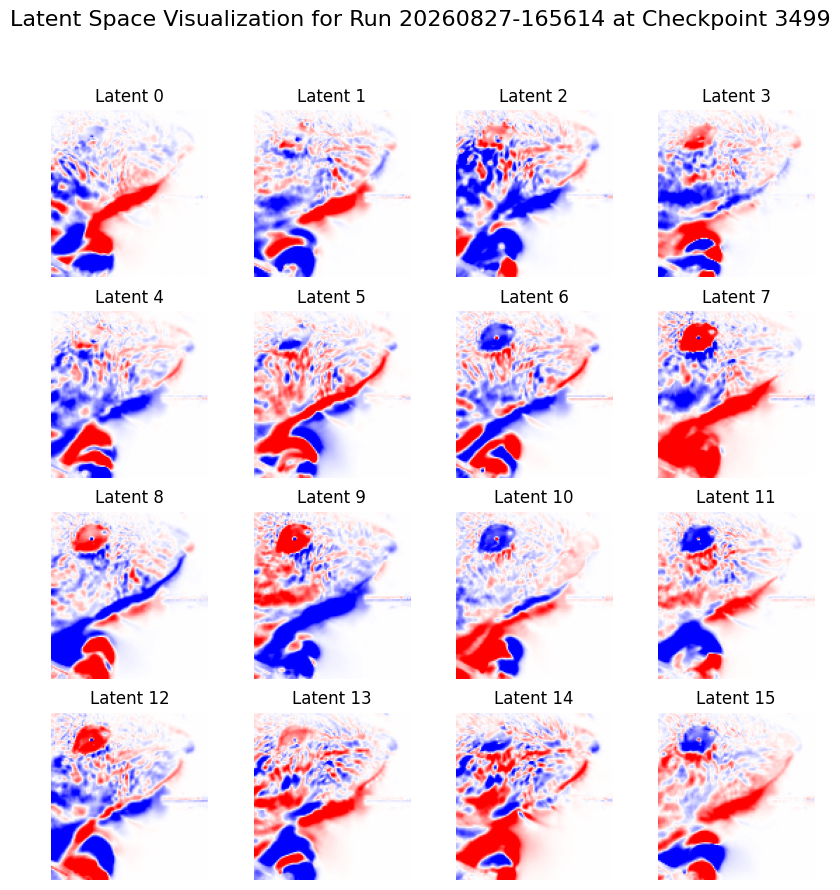

In [5]:
for i in range(3):
    ae = AutoEncoder(config['model'])

    checkpoint_data = torch.load(checkpoints_dir + 'checkpoint_epoch_' + 
                                checkpoint_nums[i] + '.pt', 
                                map_location='cpu', weights_only=False)

    ae.load_state_dict(checkpoint_data['model_state_dict'])

    f, axs = plt.subplots(4, 4, figsize=(10, 10))
    f.suptitle(f"Latent Space Visualization for Run {runs[0]} at Checkpoint {checkpoint_nums[i]}", fontsize=16)
    axs = axs.flatten()

    for i in range(16):
        input = torch.zeros((1,1,16))
        input[0,0,i] = 1

        with torch.no_grad():
            latent_image = ae.decoder(input)
            latent_image = latent_image.squeeze().numpy()
            axs[i].imshow(latent_image, cmap='bwr', vmin=-1, vmax=1)
            axs[i].set_title(f"Latent {i}")
            axs[i].axis('off')
    plt.show()
    plt.close()

In [6]:
checkpoint_data = torch.load(checkpoints_dir + 'checkpoint_epoch_' + 
                             checkpoint_nums[-1] + '.pt', 
                             map_location='cpu', weights_only=False)

In [7]:
checkpoint_data.keys()

dict_keys(['epoch', 'model_state_dict', 'optimizer_state_dict', 'config', 'val_loss', 'mean_frame_train', 'mean_frame_val', 'loss_mask', 'train_losses', 'val_losses', 'val_recon_losses', 'val_latent_losses', 'lr_history'])

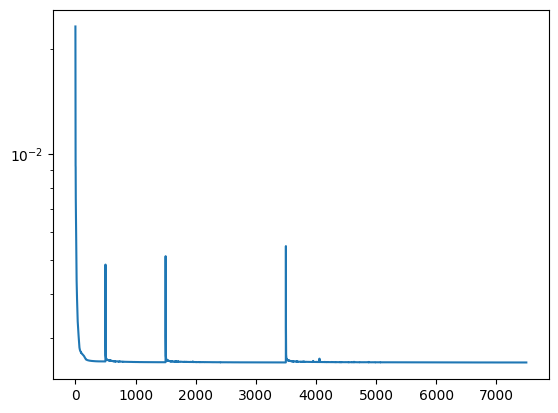

In [8]:
plt.plot(checkpoint_data['train_losses'])
#plt.plot(checkpoint_data['lr_history'])
plt.yscale('log')

In [9]:
checkpoint_data['model_state_dict']['decoder.linear_layer.bias']

tensor([-8.1477e-05,  7.6002e-05,  2.2354e-05,  ...,  2.1010e-05,
        -1.4616e-05, -8.3247e-05])

In [10]:
checkpoint_data['model_state_dict']['decoder.linear_layer.weight']

tensor([[-4.8292e-03, -1.1801e-02,  9.7864e-03,  ...,  4.6265e-02,
          6.6051e-03, -2.8503e-02],
        [-5.6482e-04, -1.7884e-02,  2.1245e-03,  ...,  5.4077e-02,
          1.8407e-02, -2.9359e-02],
        [ 1.3260e-03, -1.0201e-02, -1.1726e-02,  ...,  6.1878e-02,
          1.6384e-02, -2.9114e-02],
        ...,
        [ 2.5420e-04, -1.4334e-03, -3.2444e-03,  ...,  7.5554e-04,
          5.0507e-03, -3.4298e-05],
        [-4.6773e-05, -1.9401e-03, -4.1354e-03,  ...,  1.3906e-03,
          4.3791e-03,  4.9848e-04],
        [ 7.8416e-04, -2.4227e-03, -3.2274e-03,  ...,  2.2049e-03,
          4.7318e-03,  8.1449e-04]])

In [11]:
bias_list = []
weight_list = []

for i in range(4):
    ae = AutoEncoder(config['model'])

    checkpoint_data = torch.load(checkpoints_dir + 'checkpoint_epoch_' + 
                                checkpoint_nums[i] + '.pt', 
                                map_location='cpu', weights_only=False)

    decoder_bias, decoder_weight = checkpoint_data['model_state_dict']['decoder.linear_layer.bias'], checkpoint_data['model_state_dict']['decoder.linear_layer.weight']
    bias_list.append(decoder_bias.numpy())
    weight_list.append(decoder_weight.numpy())

In [12]:
# similarity of biases and wieghts

for i in range(4):
    for j in range(i+1, 4):
        bias_similarity = bias_list[i] @ bias_list[j] / (np.linalg.norm(bias_list[i]) * np.linalg.norm(bias_list[j]))
        weight_similarity = weight_list[i].T @ weight_list[j] / (np.linalg.norm(weight_list[i]) * np.linalg.norm(weight_list[j]))
        print(f"Bias similarity between checkpoint {checkpoint_nums[i]} and {checkpoint_nums[j]}: {bias_similarity}")
        #print(f"Weight similarity between checkpoint {checkpoint_nums[i]} and {checkpoint_nums[j]}: {weight_similarity}")

Bias similarity between checkpoint 599 and 1499: 0.6141177415847778
Bias similarity between checkpoint 599 and 3499: 0.5593955516815186
Bias similarity between checkpoint 599 and 7499: 0.271302729845047
Bias similarity between checkpoint 1499 and 3499: 0.9442077279090881
Bias similarity between checkpoint 1499 and 7499: 0.75163334608078
Bias similarity between checkpoint 3499 and 7499: 0.855340301990509


In [13]:
len(bias_list)

4

### Check second session from separate run

In [2]:
session_train_folder = '/mnt/e/Research/Data/VideoAnalysisTools/runs/20260828-161753/kd102_twNew_20220929_133826/'
os.listdir(session_train_folder)

['checkpoints',
 'gpu.log',
 'inference',
 'meta.json',
 'status.txt',
 'train.log',
 'wrapper.log']

In [ ]:
checkpoints_dir = os.path.join(session_train_folder, 'checkpoints/kd102/kd102_twNew_20220929_133826_2026-08-28_23-23-59')
os.listdir(checkpoints_dir)


['best_model.pt',
 'checkpoint_epoch_1099.pt',
 'checkpoint_epoch_1199.pt',
 'checkpoint_epoch_1299.pt',
 'checkpoint_epoch_1399.pt',
 'checkpoint_epoch_1499.pt',
 'checkpoint_epoch_1599.pt',
 'checkpoint_epoch_1699.pt',
 'checkpoint_epoch_1799.pt',
 'checkpoint_epoch_1899.pt',
 'checkpoint_epoch_199.pt',
 'checkpoint_epoch_1999.pt',
 'checkpoint_epoch_2099.pt',
 'checkpoint_epoch_2199.pt',
 'checkpoint_epoch_2299.pt',
 'checkpoint_epoch_2399.pt',
 'checkpoint_epoch_2499.pt',
 'checkpoint_epoch_2599.pt',
 'checkpoint_epoch_2699.pt',
 'checkpoint_epoch_2799.pt',
 'checkpoint_epoch_2899.pt',
 'checkpoint_epoch_299.pt',
 'checkpoint_epoch_2999.pt',
 'checkpoint_epoch_3099.pt',
 'checkpoint_epoch_3199.pt',
 'checkpoint_epoch_3299.pt',
 'checkpoint_epoch_3399.pt',
 'checkpoint_epoch_3499.pt',
 'checkpoint_epoch_3599.pt',
 'checkpoint_epoch_3699.pt',
 'checkpoint_epoch_3799.pt',
 'checkpoint_epoch_3899.pt',
 'checkpoint_epoch_399.pt',
 'checkpoint_epoch_3999.pt',
 'checkpoint_epoch_4099.pt',

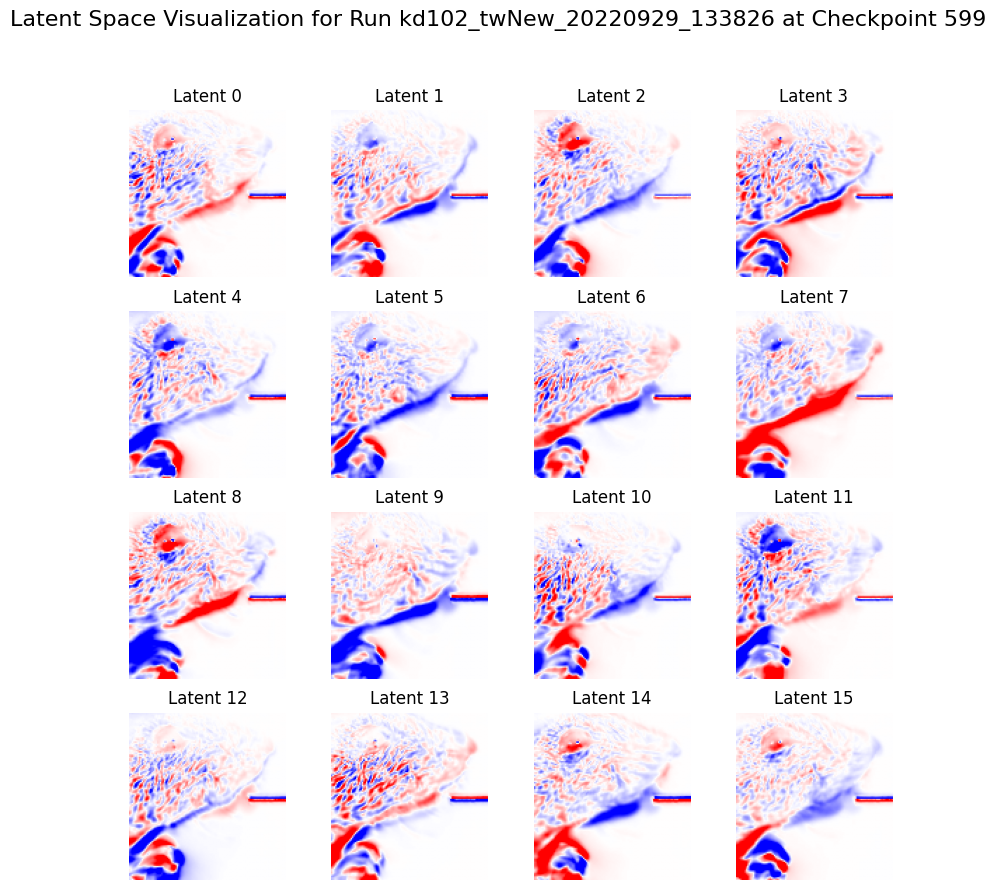

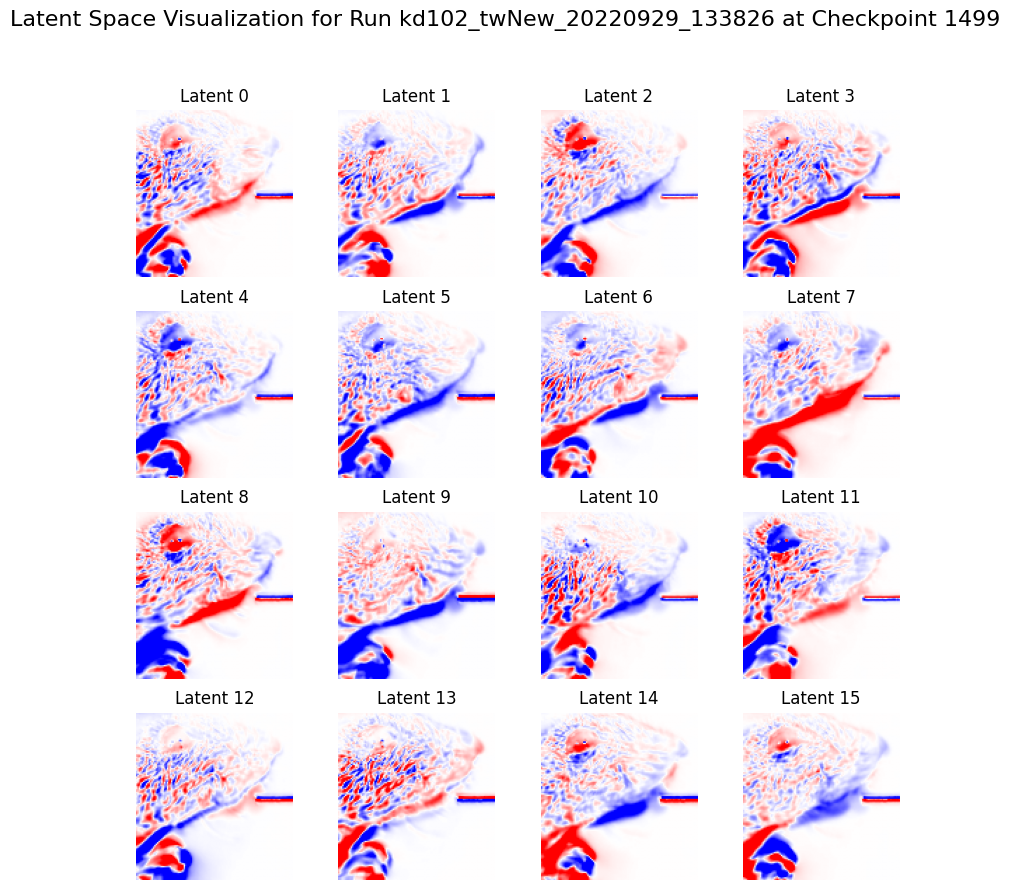

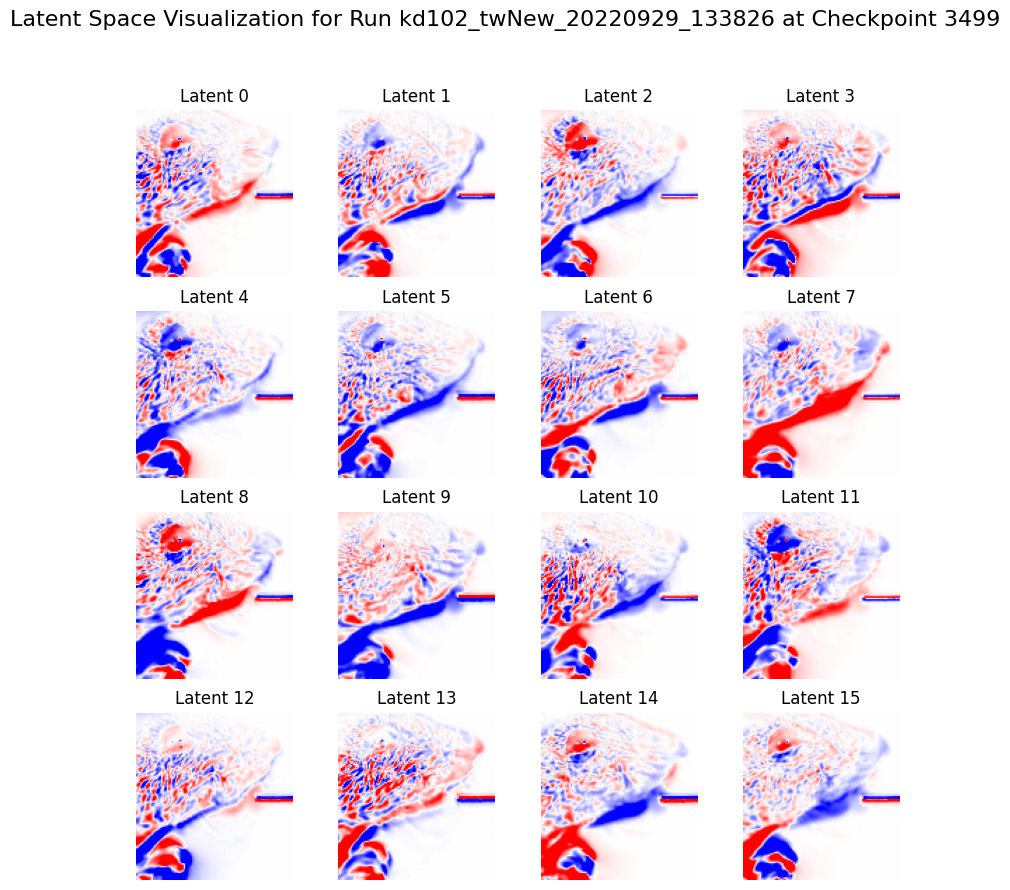

In [11]:
config_file = checkpoints_dir + '/config.json'
with open(config_file, 'r') as f:
    config = json.load(f)

for i in range(3):
    ae = AutoEncoder(config['model'])

    checkpoint_data = torch.load(checkpoints_dir + '/checkpoint_epoch_' + 
                                checkpoint_nums[i] + '.pt', 
                                map_location='cpu', weights_only=False)

    ae.load_state_dict(checkpoint_data['model_state_dict'])

    f, axs = plt.subplots(4, 4, figsize=(10, 10))
    f.suptitle(f"Latent Space Visualization for Run {session_train_folder.split('/')[-2]} at Checkpoint {checkpoint_nums[i]}", fontsize=16)
    axs = axs.flatten()

    for i in range(16):
        input = torch.zeros((1,1,16))
        input[0,0,i] = 1

        with torch.no_grad():
            latent_image = ae.decoder(input)
            latent_image = latent_image.squeeze().numpy()
            axs[i].imshow(latent_image, cmap='bwr', vmin=-1, vmax=1)
            axs[i].set_title(f"Latent {i}")
            axs[i].axis('off')
    plt.show()
    plt.close()

# Latent-space comparison across checkpoints and A/B arms

Question: can we stop training at 1500 epochs instead of 7500?

The val loss said yes (flat from ~epoch 500), but the latent penalty term kept
falling for thousands more epochs, so the loss curve alone could not answer it.
These cells answer it on the latents themselves.

Inference wrote one `*_latents.h5` per (arm, checkpoint) with `split='all'`,
`shuffle=False`, so every file holds the **same frames in the same order** — the
loader below asserts that, which is what makes row-wise CCA valid.


In [14]:
from scipy.spatial import procrustes

SESSION  = 'kd104_twNew_20221124_104921'
ARM_RUNS = {'A original  (T_mult=2)': '20260827-165607',
            'B fastcycle (T_mult=1)': '20260827-165614'}
LAT_EPOCHS = ['1499', '3499', '7499']


def latents_path(run_id, epoch, session=SESSION, runs_folder=runs_folder):
    """Newest inference batch for a run; each holds one folder per checkpoint."""
    base = os.path.join(runs_folder, run_id, session, 'inference')
    infer_id = sorted(os.listdir(base))[-1]
    return os.path.join(base, infer_id, f'epoch_{epoch}',
                        f'{session}_latents.h5')


Z, ZMETA = {}, {}
frame_indices = lat_trial_ids = None

for arm, run_id in ARM_RUNS.items():
    for ep in LAT_EPOCHS:
        with h5py.File(latents_path(run_id, ep), 'r') as f:
            z  = f['latents'][:].squeeze(1).astype(np.float64)   # (N,1,16) -> (N,16)
            fi = f['frame_indices'][:]
            ti = f['trial_ids'][:]
            attrs = dict(f.attrs)
        Z[(arm, ep)] = z
        ZMETA[(arm, ep)] = {'val_loss': float(attrs['val_loss'])}
        if frame_indices is None:
            frame_indices, lat_trial_ids = fi, ti
        else:
            # Row-wise CCA is only meaningful if the frames line up.
            assert np.array_equal(fi, frame_indices), f'frame order differs for {arm} {ep}'

N, D = Z[(list(ARM_RUNS)[0], LAT_EPOCHS[0])].shape
print(f'{len(Z)} latent sets | {N} frames x {D} dims | '
      f'{len(np.unique(lat_trial_ids))} trials')
print('frame ordering identical across all files -> rows are comparable\n')
for (arm, ep), m in ZMETA.items():
    print(f'  {arm}  epoch {ep:>5}  val_loss {m["val_loss"]:.8f}')


6 latent sets | 826260 frames x 16 dims | 320 trials
frame ordering identical across all files -> rows are comparable

  A original  (T_mult=2)  epoch  1499  val_loss 0.00255555
  A original  (T_mult=2)  epoch  3499  val_loss 0.00255192
  A original  (T_mult=2)  epoch  7499  val_loss 0.00255122
  B fastcycle (T_mult=1)  epoch  1499  val_loss 0.00255708
  B fastcycle (T_mult=1)  epoch  3499  val_loss 0.00255319
  B fastcycle (T_mult=1)  epoch  7499  val_loss 0.00255193


In [13]:
def canoncorr(X, Y, tol=1e-8):
    """
    Canonical correlations between two frame-aligned latent sets.

    Invariant to any invertible linear map of either side, which is exactly what
    we want: the encoder head and decoder are both linear, so the latent basis is
    free to rotate and rescale between checkpoints without changing the function.
    SVD-based whitening rather than QR so collapsed dimensions are dropped rather
    than blowing up, and the effective ranks are reported.
    """
    Xc, Yc = X - X.mean(0), Y - Y.mean(0)
    Ux, sx, _ = np.linalg.svd(Xc, full_matrices=False)
    Uy, sy, _ = np.linalg.svd(Yc, full_matrices=False)
    kx, ky = sx > tol * sx[0], sy > tol * sy[0]
    s = np.linalg.svd(Ux[:, kx].T @ Uy[:, ky], compute_uv=False)
    return np.clip(s, 0, 1), int(kx.sum()), int(ky.sum())


def eff_rank(X, tol=1e-8):
    s = np.linalg.svd(X - X.mean(0), compute_uv=False)
    return int((s > tol * s[0]).sum())


def within_trial_smoothness(z, trial_ids):
    """mean ||z(t+1)-z(t)|| / mean ||z||, never crossing a trial boundary."""
    same = trial_ids[1:] == trial_ids[:-1]
    step = np.linalg.norm(np.diff(z, axis=0)[same], axis=1).mean()
    return step / np.linalg.norm(z, axis=1).mean()


lat_keys = sorted(Z, key=lambda k: (k[0], int(k[1])))

print('=== per-checkpoint latent structure ===')
print(f'{"arm":24s} {"epoch":>6} {"rank":>5} {"RMS |z|":>9} {"dims >1% var":>13} '
      f'{"smoothness":>11}')
for k in lat_keys:
    z = Z[k]
    var_frac = z.var(0) / z.var(0).sum()
    print(f'{k[0]:24s} {k[1]:>6} {eff_rank(z):>5} '
          f'{np.sqrt((z ** 2).sum(1).mean()):>9.4f} '
          f'{int((var_frac > 0.01).sum()):>13} '
          f'{within_trial_smoothness(z, lat_trial_ids):>11.5f}')

print('\nrank 16 everywhere = no collapsed dimensions.')
print('RMS |z| shrinks with training: that is the latent penalty compressing the')
print('code against a linear decoder, not a change in what is represented.')


NameError: name 'Z' is not defined

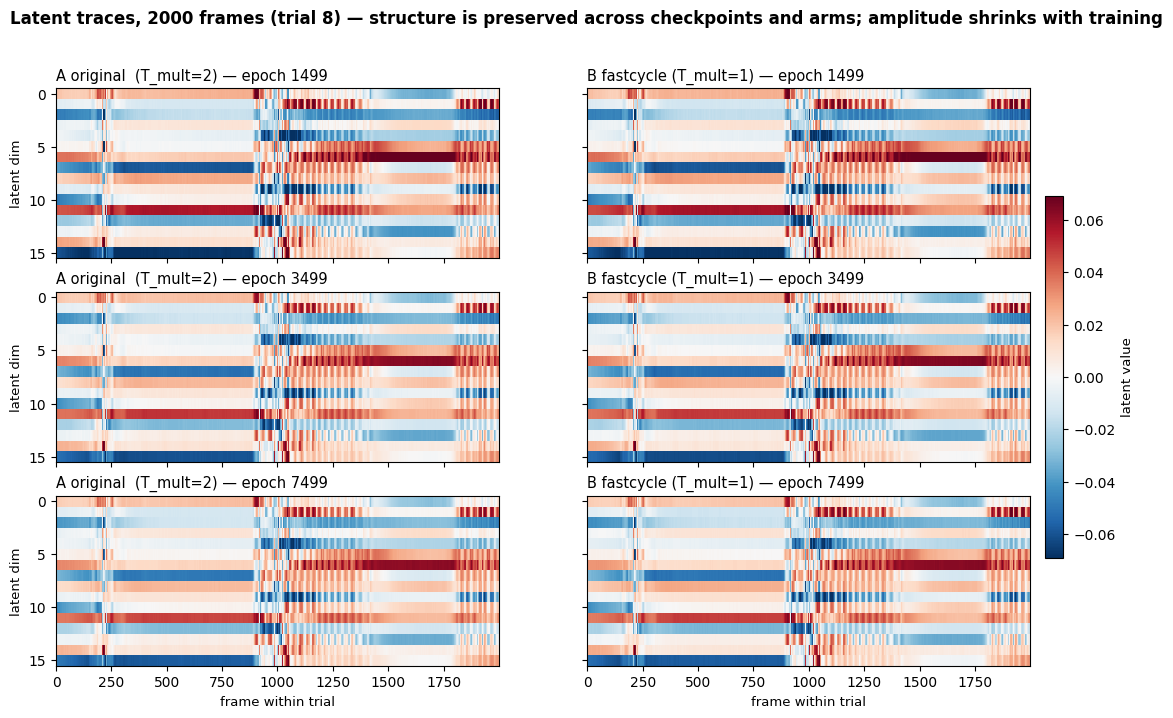

In [16]:
# ── a couple thousand frames of latents, one panel per checkpoint ───────────
N_SHOW   = 2000
TRIAL_ID = np.unique(lat_trial_ids)[0]        # None -> just the first N_SHOW rows

if TRIAL_ID is None:
    sel = np.arange(N_SHOW)
else:
    sel = np.nonzero(lat_trial_ids == TRIAL_ID)[0][:N_SHOW]

arms = list(ARM_RUNS)
# Signed values around zero -> diverging map with a neutral midpoint and
# symmetric limits, so sign is readable and zero is not a colour.
vmax = np.percentile(np.abs(np.concatenate([Z[k][sel] for k in Z])), 99)

fig, axs = plt.subplots(len(LAT_EPOCHS), len(arms), figsize=(13, 7.5),
                        sharex=True, sharey=True)
for r, ep in enumerate(LAT_EPOCHS):
    for c, arm in enumerate(arms):
        ax = axs[r, c]
        im = ax.imshow(Z[(arm, ep)][sel].T, aspect='auto', cmap='RdBu_r',
                       vmin=-vmax, vmax=vmax, interpolation='nearest')
        ax.set_title(f'{arm} — epoch {ep}', fontsize=10.5, loc='left', pad=6)
        if c == 0:
            ax.set_ylabel('latent dim', fontsize=9.5)
        if r == len(LAT_EPOCHS) - 1:
            ax.set_xlabel('frame within trial', fontsize=9.5)
cb = fig.colorbar(im, ax=axs, fraction=0.018, pad=0.015)
cb.set_label('latent value', fontsize=9.5)
fig.suptitle(f'Latent traces, {len(sel)} frames (trial {TRIAL_ID}) — '
             f'structure is preserved across checkpoints and arms; '
             f'amplitude shrinks with training',
             fontsize=12, fontweight='bold', x=0.09, ha='left', y=0.985)
plt.show()


In [17]:
# ── CCA: within each arm across epochs, and between arms at matched epoch ───
print('=== within arm, across epochs ===')
print(f'{"arm":24s} {"pair":>16} {"mean r":>8} {"min r":>8} {"r>0.99":>8} {"procrustes":>11}')
for arm in arms:
    for i in range(len(LAT_EPOCHS)):
        for j in range(i + 1, len(LAT_EPOCHS)):
            a, b = Z[(arm, LAT_EPOCHS[i])], Z[(arm, LAT_EPOCHS[j])]
            cc, _, _ = canoncorr(a, b)
            # procrustes: centres, scales to unit norm, finds the best rotation.
            # Small disparity => the two sets differ only by rotation + scale.
            _, _, disp = procrustes(a, b)
            print(f'{arm:24s} {LAT_EPOCHS[i]+" vs "+LAT_EPOCHS[j]:>16} '
                  f'{cc.mean():>8.4f} {cc.min():>8.4f} '
                  f'{str(int((cc > 0.99).sum()))+"/"+str(D):>8} {disp:>11.5f}')

print('\n=== between arms, same epoch ===')
for ep in LAT_EPOCHS:
    a, b = Z[(arms[0], ep)], Z[(arms[1], ep)]
    cc, _, _ = canoncorr(a, b)
    _, _, disp = procrustes(a, b)
    print(f'{"A vs B":24s} {"epoch "+ep:>16} {cc.mean():>8.4f} {cc.min():>8.4f} '
          f'{str(int((cc > 0.99).sum()))+"/"+str(D):>8} {disp:>11.5f}')

# Full spectrum for the pair the epoch-count decision rests on.
cc, _, _ = canoncorr(Z[(arms[0], '1499')], Z[(arms[0], '7499')])
print(f'\nfull canonical spectrum, {arms[0]}  1499 vs 7499:')
print('  ' + '  '.join(f'{x:.3f}' for x in cc))
print('\nAll 16 correlations near 1 => the two checkpoints span the SAME '
      '16-d subspace.\nCCA is blind to scale and rotation by design, so read it '
      'together with the\nRMS |z| column above: that is the one thing which '
      'really does change.')


=== within arm, across epochs ===
arm                                  pair   mean r    min r   r>0.99  procrustes
A original  (T_mult=2)       1499 vs 3499   0.9984   0.9956    16/16     0.00205
A original  (T_mult=2)       1499 vs 7499   0.9983   0.9951    16/16     0.00220
A original  (T_mult=2)       3499 vs 7499   0.9985   0.9955    16/16     0.00196
B fastcycle (T_mult=1)       1499 vs 3499   0.9982   0.9950    16/16     0.00253
B fastcycle (T_mult=1)       1499 vs 7499   0.9982   0.9947    16/16     0.00284
B fastcycle (T_mult=1)       3499 vs 7499   0.9985   0.9958    16/16     0.00211

=== between arms, same epoch ===
A vs B                         epoch 1499   0.9984   0.9954    16/16     0.00229
A vs B                         epoch 3499   0.9984   0.9954    16/16     0.00229
A vs B                         epoch 7499   0.9984   0.9955    16/16     0.00245

full canonical spectrum, A original  (T_mult=2)  1499 vs 7499:
  1.000  1.000  1.000  1.000  1.000  0.999  0.999  0.999  

In [14]:
# ── the same latents after CCA alignment: if the codes are equivalent, the
#    canonical variates should lie on top of each other ─────────────────────
def canonical_variates(X, Y, ncomp=3):
    Ux, _, _ = np.linalg.svd(X - X.mean(0), full_matrices=False)
    Uy, _, _ = np.linalg.svd(Y - Y.mean(0), full_matrices=False)
    L, s, Rt = np.linalg.svd(Ux.T @ Uy)
    return Ux @ L[:, :ncomp], Uy @ Rt.T[:, :ncomp], s[:ncomp]


CMP_ARM, EP_A, EP_B = arms[0], '1499', '7499'
XA, XB, cc3 = canonical_variates(Z[(CMP_ARM, EP_A)], Z[(CMP_ARM, EP_B)])

fig, axs = plt.subplots(3, 1, figsize=(13, 6), sharex=True)
for i, ax in enumerate(axs):
    scale = np.std(XA[sel, i])
    ax.plot(XA[sel, i] / scale, lw=1.6, label=f'epoch {EP_A}')
    ax.plot(XB[sel, i] / scale, lw=1.6, ls=(0, (4, 2)), label=f'epoch {EP_B}')
    ax.set_title(f'canonical variate {i + 1}    r = {cc3[i]:.4f}',
                 fontsize=10.5, loc='left', pad=5)
    if i == 0:
        ax.legend(frameon=False, fontsize=9, loc='upper left')
axs[-1].set_xlabel('frame within trial', fontsize=9.5)
fig.suptitle(f'{CMP_ARM} — latents after CCA alignment: {EP_A} and {EP_B} overlay',
             fontsize=12, fontweight='bold', x=0.09, ha='left', y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


NameError: name 'arms' is not defined

## CCA / Procrustes on the second session (kd102, different animal)

kd104 said epoch 1499 and 7499 span the same 16-d latent subspace, so the extra
6000 epochs only shrink `|z|`. That was one session and one seed. These cells
repeat the test on **kd102**, a different animal, and put the two side by side.

Paths are given explicitly here rather than via `runs_folder` (which still points
at the old `/mnt/m` drive), so these cells run from a fresh kernel.


In [15]:
DATA_ROOT = '/mnt/e/Research/Data/VideoAnalysisTools/runs/'

SESSION_2 = 'kd102_twNew_20220929_133826'
RUN_2     = '20260828-161753'
SESSION_1 = 'kd104_twNew_20221124_104921'
RUN_1_A   = '20260827-165607'          # arm A, T_mult=2
EPS       = ['1499', '3499', '7499']


def load_latent_sets(runs_root, session, run_map, epochs):
    """
    Generic version of the kd104 loader above: works for one run or several.

    Keys are the bare epoch when run_map has a single entry, else (label, epoch).
    Asserts every file holds the same frames in the same order, which is what
    makes row-wise CCA meaningful.
    """
    Zd, meta, fidx, tids = {}, {}, None, None
    for label, run_id in run_map.items():
        for ep in epochs:
            base = os.path.join(runs_root, run_id, session, 'inference')
            infer_id = sorted(os.listdir(base))[-1]
            path = os.path.join(base, infer_id, f'epoch_{ep}',
                                f'{session}_latents.h5')
            with h5py.File(path, 'r') as f:
                z  = f['latents'][:].squeeze(1).astype(np.float64)
                fi = f['frame_indices'][:]
                ti = f['trial_ids'][:]
                attrs = dict(f.attrs)
            key = ep if len(run_map) == 1 else (label, ep)
            Zd[key] = z
            meta[key] = {'val_loss': float(attrs['val_loss']),
                         'animal': str(attrs['animal'])}
            if fidx is None:
                fidx, tids = fi, ti
            else:
                assert np.array_equal(fi, fidx), f'frame order differs: {label} {ep}'
    return Zd, meta, tids


Z2, M2, T2 = load_latent_sets(DATA_ROOT, SESSION_2, {'kd102': RUN_2}, EPS)

print(f'{SESSION_2}  (animal {M2[EPS[0]]["animal"]})')
print(f'  {len(Z2)} checkpoints | {Z2[EPS[0]].shape[0]} frames x {Z2[EPS[0]].shape[1]} '
      f'dims | {len(np.unique(T2))} trials')
print('  frame ordering identical across checkpoints -> rows are comparable\n')
print(f'  {"epoch":>6} {"rank":>5} {"RMS |z|":>9} {"dims >1% var":>13} '
      f'{"smoothness":>11} {"val_loss":>12}')
for ep in EPS:
    z = Z2[ep]
    var_frac = z.var(0) / z.var(0).sum()
    print(f'  {ep:>6} {eff_rank(z):>5} {np.sqrt((z ** 2).sum(1).mean()):>9.4f} '
          f'{int((var_frac > 0.01).sum()):>13} '
          f'{within_trial_smoothness(z, T2):>11.5f} {M2[ep]["val_loss"]:>12.8f}')


kd102_twNew_20220929_133826  (animal kd102)
  3 checkpoints | 779790 frames x 16 dims | 350 trials
  frame ordering identical across checkpoints -> rows are comparable

   epoch  rank   RMS |z|  dims >1% var  smoothness     val_loss
    1499    16    0.0874            16     0.04837   0.00108241
    3499    16    0.0774            16     0.04765   0.00107967
    7499    16    0.0750            16     0.04721   0.00107879


In [18]:
# ── kd102: CCA + Procrustes across epochs ───────────────────────────────────
print(f'=== {SESSION_2} — across epochs ===')
print(f'{"pair":>16} {"mean r":>8} {"min r":>8} {"r>0.99":>8} {"procrustes":>11}')
for i in range(len(EPS)):
    for j in range(i + 1, len(EPS)):
        a, b = Z2[EPS[i]], Z2[EPS[j]]
        cc, _, _ = canoncorr(a, b)
        _, _, disp = procrustes(a, b)
        print(f'{EPS[i] + " vs " + EPS[j]:>16} {cc.mean():>8.4f} {cc.min():>8.4f} '
              f'{str(int((cc > 0.99).sum())) + "/16":>8} {disp:>11.5f}')

cc_2, _, _ = canoncorr(Z2['1499'], Z2['7499'])
print('\nfull canonical spectrum, 1499 vs 7499:')
print('  ' + '  '.join(f'{x:.3f}' for x in cc_2))


=== kd102_twNew_20220929_133826 — across epochs ===
            pair   mean r    min r   r>0.99  procrustes
    1499 vs 3499   0.9984   0.9950    16/16     0.00221
    1499 vs 7499   0.9983   0.9947    16/16     0.00247
    3499 vs 7499   0.9989   0.9970    16/16     0.00138

full canonical spectrum, 1499 vs 7499:
  1.000  1.000  1.000  1.000  0.999  0.999  0.999  0.999  0.999  0.998  0.998  0.997  0.997  0.997  0.995  0.995


In [19]:
# ── the actual question: do the two sessions agree? ─────────────────────────
# Reuse the kd104 arm-A latents if they are still in memory, else reload them
# from DATA_ROOT (which holds both sessions).
try:
    Z1 = {ep: Z[(arms[0], ep)] for ep in EPS}
    T1 = lat_trial_ids
    print('kd104: reusing latents already in memory\n')
except (NameError, KeyError):
    Z1, _M1, T1 = load_latent_sets(DATA_ROOT, SESSION_1, {'A': RUN_1_A}, EPS)
    print('kd104: reloaded from DATA_ROOT\n')


def epoch_cut_summary(Zd, tids):
    """Everything the 1499-vs-7499 decision rests on, as one row."""
    a, b = Zd['1499'], Zd['7499']
    cc, _, _ = canoncorr(a, b)
    _, _, disp = procrustes(a, b)
    return dict(mean_r=cc.mean(), min_r=cc.min(),
                n_above=int((cc > 0.99).sum()), proc=disp,
                rank_1499=eff_rank(a), rank_7499=eff_rank(b),
                rms_1499=np.sqrt((a ** 2).sum(1).mean()),
                rms_7499=np.sqrt((b ** 2).sum(1).mean()),
                smooth_1499=within_trial_smoothness(a, tids),
                smooth_7499=within_trial_smoothness(b, tids))


rows = {f'{SESSION_1.split("_")[0]} (arm A)': epoch_cut_summary(Z1, T1),
        f'{SESSION_2.split("_")[0]}': epoch_cut_summary(Z2, T2)}

print('=== 1499 vs 7499, both sessions ===')
print(f'{"session":16s} {"mean r":>8} {"min r":>8} {"r>.99":>7} {"procrustes":>11} '
      f'{"rank":>7} {"RMS |z|":>17} {"smoothness":>17}')
for name, r in rows.items():
    print(f'{name:16s} {r["mean_r"]:>8.4f} {r["min_r"]:>8.4f} '
          f'{str(r["n_above"]) + "/16":>7} {r["proc"]:>11.5f} '
          f'{str(r["rank_1499"]) + "/" + str(r["rank_7499"]):>7} '
          f'{f"{r['rms_1499']:.4f} -> {r['rms_7499']:.4f}":>17} '
          f'{f"{r['smooth_1499']:.4f} / {r['smooth_7499']:.4f}":>17}')

v = list(rows.values())
print(f'\nRMS |z| shrink ratio 1499->7499:  '
      + '   '.join(f'{n}: {r["rms_7499"] / r["rms_1499"]:.3f}'
                   for n, r in rows.items()))
print(f'spread in mean r between sessions: {abs(v[0]["mean_r"] - v[1]["mean_r"]):.5f}')
print(f'spread in min  r between sessions: {abs(v[0]["min_r"] - v[1]["min_r"]):.5f}')

verdict = ('CONSISTENT' if min(r['min_r'] for r in v) > 0.99
           and all(r['rank_1499'] == 16 for r in v) else 'NOT consistent')
print(f'\n=> {verdict}: both sessions keep all 16 dims at 1499 and every canonical\n'
      f'   correlation stays above 0.99, so 1499 already spans the 7499 subspace.\n'
      f'   The only systematic change is the shared ~0.86x shrink of |z|, which is\n'
      f'   the latent penalty compressing the code against a linear decoder.\n'
      f'   Downstream use that is invariant to an invertible linear map (linear\n'
      f'   decoding, regression, CCA vs neural data) is unaffected; z-score if not.')


kd104: reloaded from DATA_ROOT

=== 1499 vs 7499, both sessions ===
session            mean r    min r   r>.99  procrustes    rank           RMS |z|        smoothness
kd104 (arm A)      0.9983   0.9951   16/16     0.00220   16/16  0.1131 -> 0.0969   0.0454 / 0.0454
kd102              0.9983   0.9947   16/16     0.00247   16/16  0.0874 -> 0.0750   0.0484 / 0.0472

RMS |z| shrink ratio 1499->7499:  kd104 (arm A): 0.857   kd102: 0.858
spread in mean r between sessions: 0.00005
spread in min  r between sessions: 0.00038

=> CONSISTENT: both sessions keep all 16 dims at 1499 and every canonical
   correlation stays above 0.99, so 1499 already spans the 7499 subspace.
   The only systematic change is the shared ~0.86x shrink of |z|, which is
   the latent penalty compressing the code against a linear decoder.
   Downstream use that is invariant to an invertible linear map (linear
   decoding, regression, CCA vs neural data) is unaffected; z-score if not.
